In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ali830/energydata/energydata_complete.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/ali830/energydata/energydata_complete.csv')
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [4]:
df.shape
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19735 entries, 0 to 19734
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         19735 non-null  object 
 1   Appliances   19735 non-null  int64  
 2   lights       19735 non-null  int64  
 3   T1           19735 non-null  float64
 4   RH_1         19735 non-null  float64
 5   T2           19735 non-null  float64
 6   RH_2         19735 non-null  float64
 7   T3           19735 non-null  float64
 8   RH_3         19735 non-null  float64
 9   T4           19735 non-null  float64
 10  RH_4         19735 non-null  float64
 11  T5           19735 non-null  float64
 12  RH_5         19735 non-null  float64
 13  T6           19735 non-null  float64
 14  RH_6         19735 non-null  float64
 15  T7           19735 non-null  float64
 16  RH_7         19735 non-null  float64
 17  T8           19735 non-null  float64
 18  RH_8         19735 non-null  float64
 19  T9  

,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
count,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,...,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000,19735.000000
mean,97.694958,3.801875,21.686571,40.259739,20.341219,40.420420,22.267611,39.242500,20.855335,39.026904,...,19.485828,41.552401,7.411665,755.522602,79.750418,4.039752,38.330834,3.760707,24.988033,24.988033
std,102.524891,7.935988,1.606066,3.979299,2.192974,4.069813,2.006111,3.254576,2.042884,4.341321,...,2.014712,4.151497,5.317409,7.399441,14.901088,2.451221,11.794719,4.194648,14.496634,14.496634
min,10.000000,0.000000,16.790000,27.023333,16.100000,20.463333,17.200000,28.766667,15.100000,27.660000,...,14.890000,29.166667,-5.000000,729.300000,24.000000,0.000000,1.000000,-6.600000,0.005322,0.005322
25%,50.000000,0.000000,20.760000,37.333333,18.790000,37.900000,20.790000,36.900000,19.530000,35.530000,...,18.000000,38.500000,3.666667,750.933333,70.333333,2.000000,29.000000,0.900000,12.497889,12.497889
50%,60.000000,0.000000,21.600000,39.656667,20.000000,40.500000,22.100000,38.530000,20.666667,38.400000,...,19.390000,40.900000,6.916667,756.100000,83.666667,3.666667,40.000000,3.433333,24.897653,24.897653
75%,100.000000,0.000000,22.600000,43.066667,21.500000,43.260000,23.290000,41.760000,22.100000,42.156667,...,20.600000,44.338095,10.408333,760.933333,91.666667,5.500000,40.000000,6.566667,37.583769,37.583769
max,1080.000000,70.000000,26.260000,63.360000,29.856667,56.026667,29.236000,50.163333,26.200000,51.090000,...,24.500000,53.326667,26.100000,772.300000,100.000000,14.000000,66.000000,15.500000,49.996530,49.996530


In [5]:
df.isnull().sum()

date           0
Appliances     0
lights         0
T1             0
RH_1           0
T2             0
RH_2           0
T3             0
RH_3           0
T4             0
RH_4           0
T5             0
RH_5           0
T6             0
RH_6           0
T7             0
RH_7           0
T8             0
RH_8           0
T9             0
RH_9           0
T_out          0
Press_mm_hg    0
RH_out         0
Windspeed      0
Visibility     0
Tdewpoint      0
rv1            0
rv2            0
dtype: int64

In [6]:
# First, see what's in the datasets folder
import os
print("Available files/folders:")
print(os.listdir('/kaggle/input/datasets'))

Available files/folders:
['ali830']


In [7]:
import pandas as pd

# Adjust 'your_file.csv' to match whatever file is inside datasets folder
df = pd.read_csv('/kaggle/input/datasets/ali830/energydata/energydata_complete.csv')
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [8]:
import os
folder_path = '/kaggle/input/datasets'
print(os.listdir(folder_path))

['ali830']


In [9]:
import os
print(os.listdir('/kaggle/input/datasets/ali830'))

['energydata']


In [10]:
import os
print(os.listdir('/kaggle/input/datasets/ali830/energydata'))

['energydata_complete.csv']


In [11]:
import pandas as pd

# Replace 'your_file.csv' with whatever filename appears from the command above
df = pd.read_csv('/kaggle/input/datasets/ali830/energydata/energydata_complete.csv')
df.head()

,date,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,...,T9,RH_9,T_out,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2
0,2016-01-11 17:00:00,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,...,17.033333,45.53,6.600000,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433
1,2016-01-11 17:10:00,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,...,17.066667,45.56,6.483333,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195
2,2016-01-11 17:20:00,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,...,17.000000,45.50,6.366667,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668
3,2016-01-11 17:30:00,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,...,17.000000,45.40,6.250000,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389
4,2016-01-11 17:40:00,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,...,17.000000,45.40,6.133333,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097


In [12]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract useful time features
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month

# Drop original date column (not needed for model)
df = df.drop('date', axis=1)

print("✅ Date features extracted!")
print(f"New shape: {df.shape}")
df.head()

✅ Date features extracted!
New shape: (19735, 31)


,Appliances,lights,T1,RH_1,T2,RH_2,T3,RH_3,T4,RH_4,...,Press_mm_hg,RH_out,Windspeed,Visibility,Tdewpoint,rv1,rv2,hour,day_of_week,month
0,60,30,19.89,47.596667,19.2,44.790000,19.79,44.730000,19.000000,45.566667,...,733.5,92.0,7.000000,63.000000,5.3,13.275433,13.275433,17,0,1
1,60,30,19.89,46.693333,19.2,44.722500,19.79,44.790000,19.000000,45.992500,...,733.6,92.0,6.666667,59.166667,5.2,18.606195,18.606195,17,0,1
2,50,30,19.89,46.300000,19.2,44.626667,19.79,44.933333,18.926667,45.890000,...,733.7,92.0,6.333333,55.333333,5.1,28.642668,28.642668,17,0,1
3,50,40,19.89,46.066667,19.2,44.590000,19.79,45.000000,18.890000,45.723333,...,733.8,92.0,6.000000,51.500000,5.0,45.410389,45.410389,17,0,1
4,60,40,19.89,46.333333,19.2,44.530000,19.79,45.000000,18.890000,45.530000,...,733.9,92.0,5.666667,47.666667,4.9,10.084097,10.084097,17,0,1


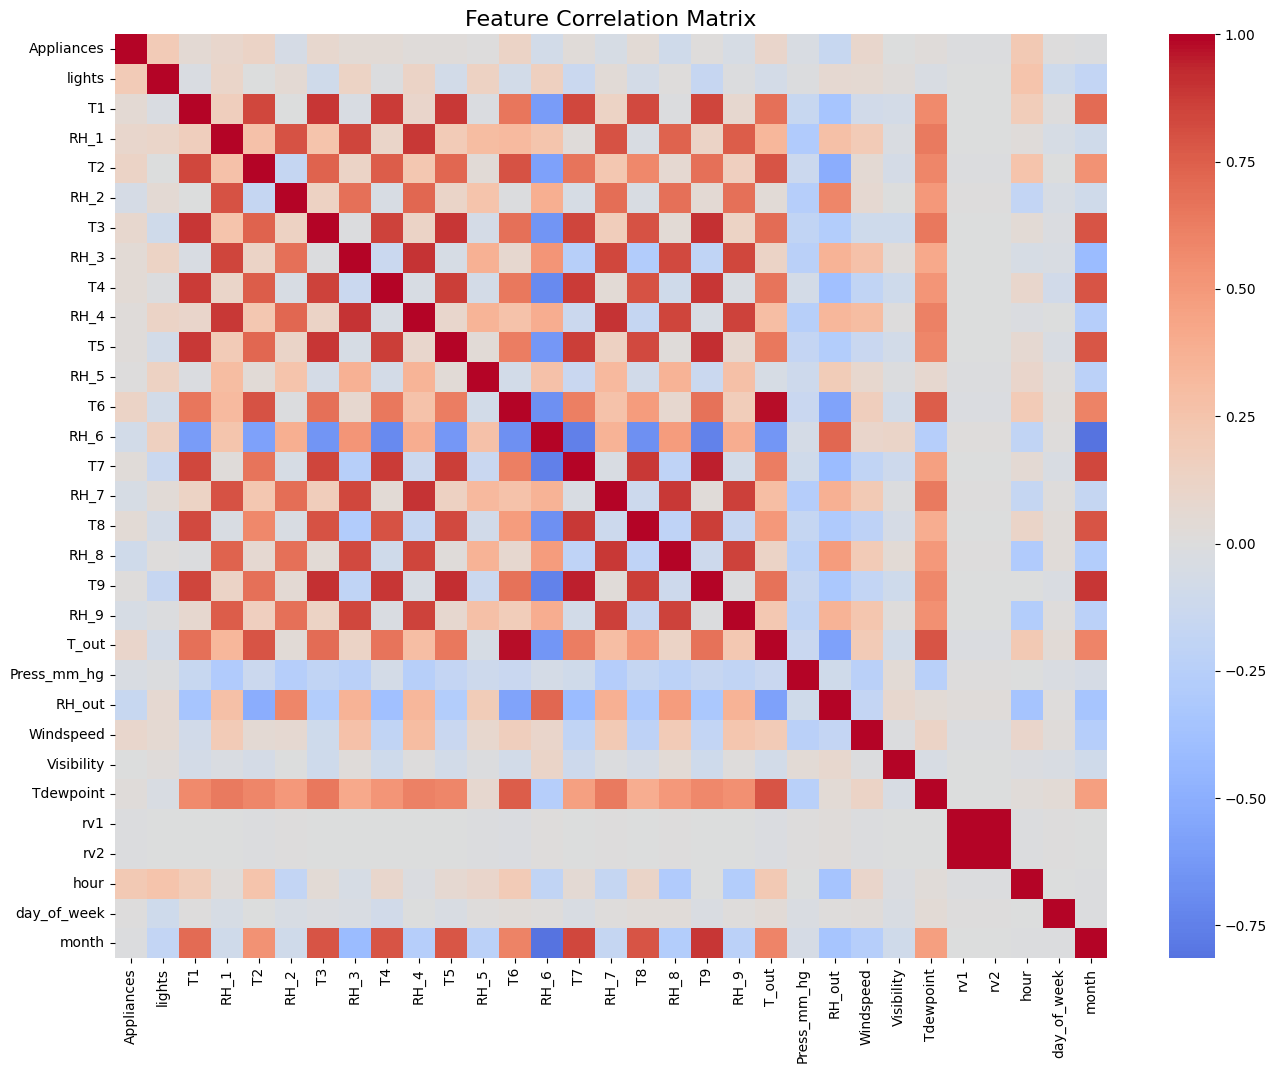

Top 10 features correlated with Appliances:
Appliances    1.000000
hour          0.216792
lights        0.197278
T2            0.120073
T6            0.117638
T_out         0.099155
Windspeed     0.087122
RH_1          0.086031
T3            0.085060
T1            0.055447
T4            0.040281
Name: Appliances, dtype: float64


In [13]:
plt.figure(figsize=(16, 12))
sns.heatmap(df.corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix', fontsize=16)
plt.show()

# Show top correlations with Appliances (target)
print("Top 10 features correlated with Appliances:")
corr_with_target = df.corr()['Appliances'].sort_values(ascending=False)
print(corr_with_target.head(11))  # 11 because first is Appliances itself

In [14]:
# Target variable: Appliances energy consumption
y = df['Appliances']

# Features: all columns except Appliances
X = df.drop('Appliances', axis=1)

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (19735, 30)
Target shape: (19735,)


In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")

Training set size: 15788 samples
Testing set size: 3947 samples


In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Features scaled successfully!")

✅ Features scaled successfully!


In [17]:
from sklearn.ensemble import RandomForestRegressor

# Initialize and train model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

print("✅ Random Forest model trained successfully!")

✅ Random Forest model trained successfully!


In [18]:
# Predict on test set
y_pred_rf = rf_model.predict(X_test_scaled)

# Show actual vs predicted for first 10 samples
comparison_df = pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred_rf[:10]
})
comparison_df['Difference'] = comparison_df['Actual'] - comparison_df['Predicted']
print("First 10 predictions vs actual values:")
print(comparison_df.round(2))

First 10 predictions vs actual values:
   Actual  Predicted  Difference
0      40       52.1       -12.1
1      90      108.3       -18.3
2      50       45.3         4.7
3      50       63.1       -13.1
4      70       72.1        -2.1
5     120      122.7        -2.7
6     120      120.5        -0.5
7      70      105.5       -35.5
8      50       51.1        -1.1
9      70       96.9       -26.9


In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("="*50)
print("RANDOM FOREST MODEL PERFORMANCE")
print("="*50)
print(f"Mean Absolute Error (MAE): {mae:.2f} Wh")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} Wh")
print(f"R² Score: {r2:.4f}")
print("="*50)

RANDOM FOREST MODEL PERFORMANCE
Mean Absolute Error (MAE): 32.08 Wh
Mean Squared Error (MSE): 4518.78
Root Mean Squared Error (RMSE): 67.22 Wh
R² Score: 0.5484


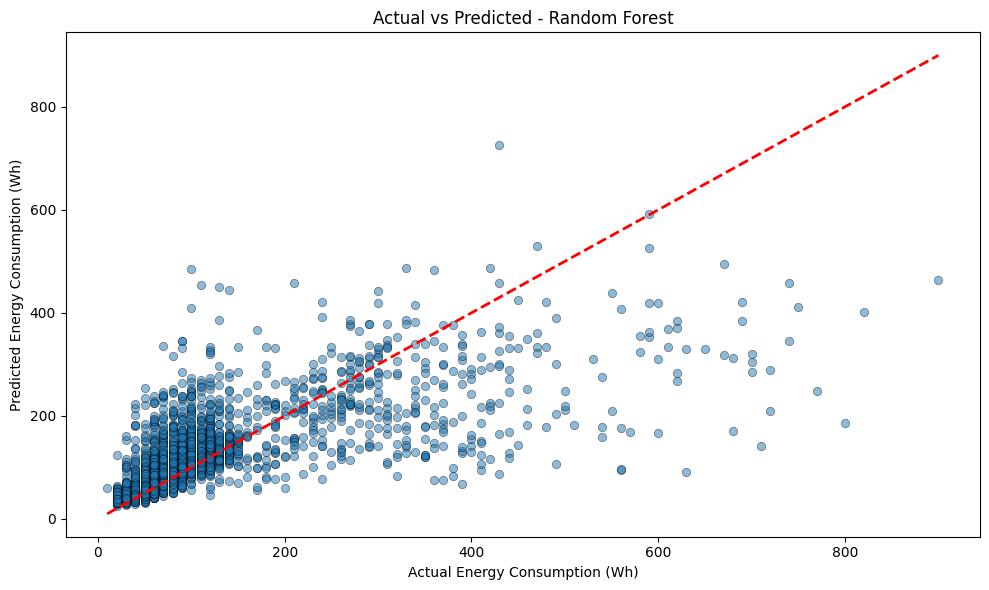

In [20]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Energy Consumption (Wh)')
plt.ylabel('Predicted Energy Consumption (Wh)')
plt.title('Actual vs Predicted - Random Forest')
plt.tight_layout()
plt.show()

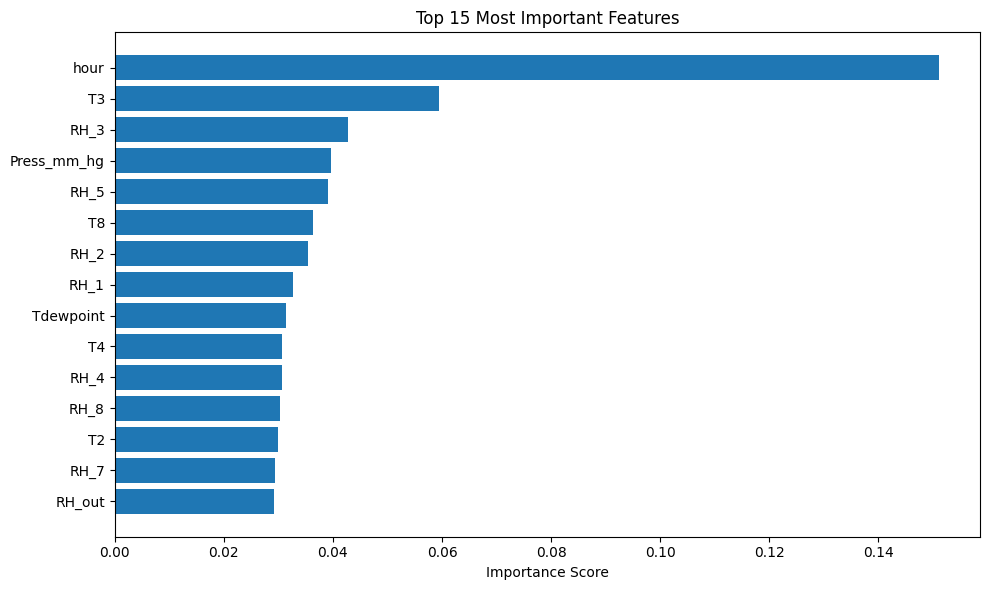

Top 10 Most Important Features:
        Feature  Importance
27         hour    0.151060
5            T3    0.059362
6          RH_3    0.042851
20  Press_mm_hg    0.039631
10         RH_5    0.039122
15           T8    0.036295
4          RH_2    0.035364
2          RH_1    0.032711
24    Tdewpoint    0.031388
7            T4    0.030739


In [21]:
# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'].head(15)[::-1], 
         feature_importance['Importance'].head(15)[::-1])
plt.xlabel('Importance Score')
plt.title('Top 15 Most Important Features')
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
print(feature_importance.head(10))

In [22]:
from sklearn.linear_model import LinearRegression

# Train linear model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predict and evaluate
y_pred_lr = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, y_pred_lr)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)

print("="*50)
print("LINEAR REGRESSION BASELINE PERFORMANCE")
print("="*50)
print(f"MAE: {lr_mae:.2f} Wh")
print(f"RMSE: {lr_rmse:.2f} Wh")
print(f"R² Score: {lr_r2:.4f}")
print("="*50)

LINEAR REGRESSION BASELINE PERFORMANCE
MAE: 52.55 Wh
RMSE: 91.09 Wh
R² Score: 0.1708


In [23]:
# Comparison summary
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE (Wh)': [lr_mae, mae],
    'RMSE (Wh)': [lr_rmse, rmse],
    'R² Score': [lr_r2, r2]
})

print("="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)
print(comparison.round(4))
print("="*50)

# Determine best model
if r2 > lr_r2:
    print(f"✅ Random Forest outperforms Linear Regression by {(r2 - lr_r2)*100:.2f}% in R² score")
else:
    print(f"✅ Linear Regression performs better")

MODEL COMPARISON SUMMARY
               Model  MAE (Wh)  RMSE (Wh)  R² Score
0  Linear Regression   52.5541    91.0929    0.1708
1      Random Forest   32.0780    67.2219    0.5484
✅ Random Forest outperforms Linear Regression by 37.76% in R² score


In [24]:
print("="*60)
print("PHASE 4 METHODOLOGY SUMMARY")
print("="*60)
print("""
1. DATA PREPROCESSING:
   - Loaded 19,735 samples with 29 features
   - No missing values detected
   - Extracted time features (hour, day_of_week, month) from datetime
   - Applied StandardScaler for feature normalization

2. MODEL IMPLEMENTATION:
   - Random Forest Regressor (100 trees)
   - Linear Regression (baseline comparison)
   - 80-20 train-test split

3. RESULTS:
   - Random Forest R² Score: {:.4f}
   - Linear Regression R² Score: {:.4f}
   - Best Model: {}

4. KEY FINDINGS:
   - Temperature and humidity sensors show strong correlation with energy use
   - Time-based features (hour, day) contribute to prediction accuracy
   - Random Forest captures non-linear relationships better than Linear Regression

5. OBJECTIVES ACHIEVED:
   - Successfully predicted appliance energy consumption
   - Identified key factors affecting energy usage
   - Built robust model for energy forecasting
""".format(r2, lr_r2, 
           "Random Forest" if r2 > lr_r2 else "Linear Regression"))
print("="*60)

PHASE 4 METHODOLOGY SUMMARY

1. DATA PREPROCESSING:
   - Loaded 19,735 samples with 29 features
   - No missing values detected
   - Extracted time features (hour, day_of_week, month) from datetime
   - Applied StandardScaler for feature normalization

2. MODEL IMPLEMENTATION:
   - Random Forest Regressor (100 trees)
   - Linear Regression (baseline comparison)
   - 80-20 train-test split

3. RESULTS:
   - Random Forest R² Score: 0.5484
   - Linear Regression R² Score: 0.1708
   - Best Model: Random Forest

4. KEY FINDINGS:
   - Temperature and humidity sensors show strong correlation with energy use
   - Time-based features (hour, day) contribute to prediction accuracy
   - Random Forest captures non-linear relationships better than Linear Regression

5. OBJECTIVES ACHIEVED:
   - Successfully predicted appliance energy consumption
   - Identified key factors affecting energy usage
   - Built robust model for energy forecasting

